# Machine Learning 1 - Steel Plates Fault Classification

## Model Classification

**Nama:** Bartholomeus Mack Theo Sinaga  
**Role:** ML Engineer 1  
**Dataset:** Steel Plates Faults

### Tujuan

Membangun model Machine Learning supervised untuk melakukan klasifikasi
jenis kerusakan pada steel plate berdasarkan feature hasil preprocessing
Data Engineer.

### Tahapan

1. Load dataset training dan testing
2. Pemeriksaan data
3. Pemisahan feature dan target
4. Feature scaling
5. Training beberapa model classification
6. Evaluasi model
7. Perbandingan hasil model
8. Pemilihan model berdasarkan metrik evaluasi
9. Training final model
10. Penyimpanan model untuk digunakan oleh backend

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Library berhasil di-import.")

Library berhasil di-import.


In [3]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print("Training dataset:", train_df.shape)
print("Testing dataset :", test_df.shape)

Training dataset: (1552, 30)
Testing dataset : (389, 30)


In [4]:
X_train = train_df.drop(columns=["Defect_Type"])
y_train = train_df["Defect_Type"]

X_test = test_df.drop(columns=["Defect_Type"])
y_test = test_df["Defect_Type"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (1552, 29)
y_train: (1552,)
X_test : (389, 29)
y_test : (389,)


In [5]:
scaler = joblib.load("../models/standard_scaler.pkl")

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling berhasil.")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

Scaling berhasil.
X_train_scaled: (1552, 29)
X_test_scaled : (389, 29)


c:\Users\Lenovo\anaconda3\envs\ml_env\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


##  Training Classification Models

Beberapa algoritma classification digunakan untuk membandingkan
performa model pada dataset Steel Plates Faults.

Model yang digunakan:

1. Logistic Regression
2. Random Forest
3. K-Nearest Neighbors
4. Support Vector Machine

In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        kernel="rbf",
        random_state=42
    )
}

print("Model yang akan diuji:")

for name in models:
    print("-", name)

Model yang akan diuji:
- Logistic Regression
- Random Forest
- KNN
- SVM


In [7]:
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(
        X_train_scaled,
        y_train
    )

    trained_models[name] = model

    print(f"{name} selesai.")


Training Logistic Regression...
Logistic Regression selesai.

Training Random Forest...
Random Forest selesai.

Training KNN...
KNN selesai.

Training SVM...
SVM selesai.


##  Classification Report

Classification report digunakan untuk melihat performa Random Forest
pada masing-masing kelas berdasarkan precision, recall, dan F1-score.

Evaluasi per kelas penting karena dataset memiliki distribusi kelas
yang tidak seimbang.

In [16]:
rf_model = trained_models["Random Forest"]

y_pred_rf = rf_model.predict(X_test_scaled)

print("Classification Report - Random Forest")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, zero_division=0))

Classification Report - Random Forest
              precision    recall  f1-score   support

       Bumps       0.72      0.69      0.70        81
   Dirtiness       0.82      0.82      0.82        11
    K_Scatch       0.97      0.90      0.93        78
Other_Faults       0.71      0.83      0.77       135
      Pastry       0.74      0.53      0.62        32
      Stains       0.92      0.86      0.89        14
   Z_Scratch       0.97      0.89      0.93        38

    accuracy                           0.80       389
   macro avg       0.84      0.79      0.81       389
weighted avg       0.80      0.80      0.80       389



## Confusion Matrix

Confusion matrix digunakan untuk melihat distribusi prediksi benar
dan kesalahan klasifikasi pada setiap kelas.

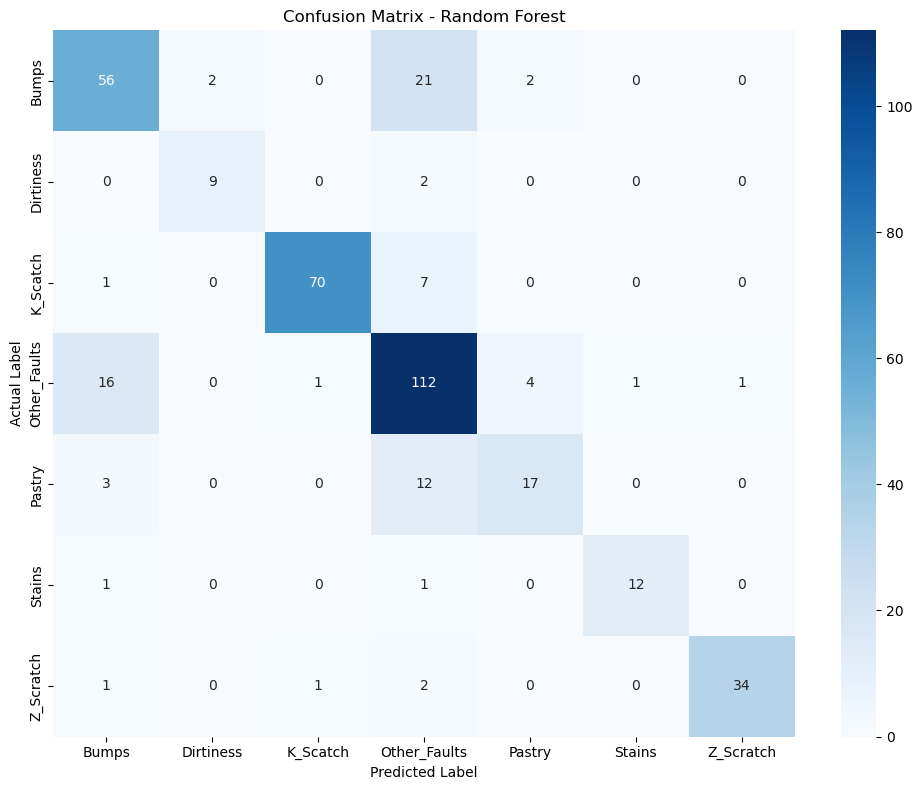

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=rf_model.classes_
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

##  Feature Importance

Feature importance digunakan untuk melihat fitur yang paling berkontribusi
dalam proses pengambilan keputusan Random Forest.

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
10,Length_of_Conveyer,0.059972
22,Log_X_Index,0.053134
21,LogOfAreas,0.049961
4,Pixels_Areas,0.047633
13,Steel_Plate_Thickness,0.047547
27,Defect_Width,0.044968
7,Sum_of_Luminosity,0.044407
8,Minimum_of_Luminosity,0.044078
1,X_Maximum,0.039602
17,Outside_X_Index,0.039398


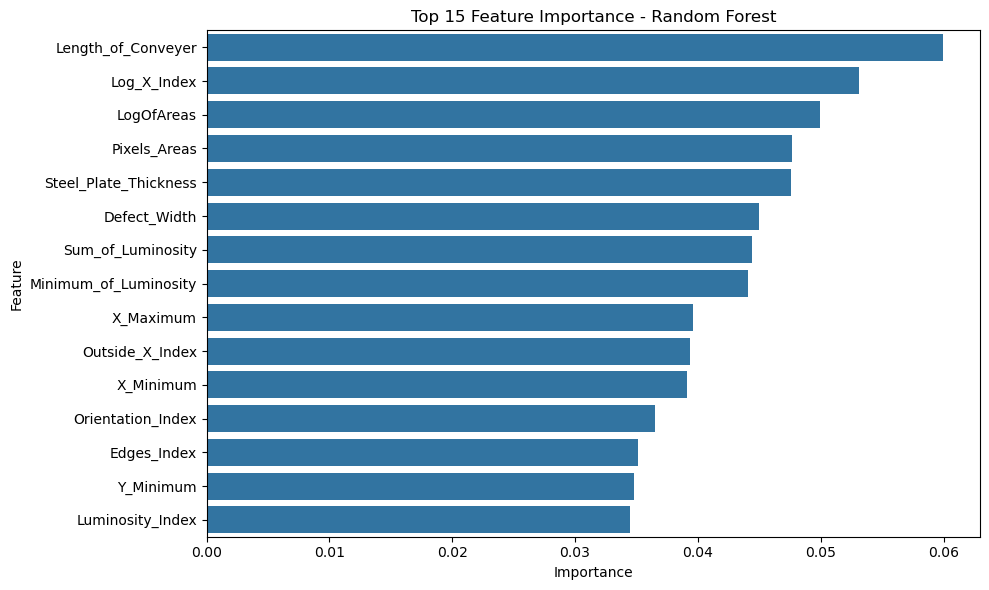

In [19]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##  Analysis

Random Forest menghasilkan performa yang lebih tinggi dibandingkan model
lain yang diuji berdasarkan accuracy, precision macro, recall macro,
dan F1 macro.

Pada evaluasi per kelas, K_Scatch dan Z_Scratch memiliki recall yang
tinggi. Sementara itu, kelas Pastry memiliki recall yang lebih rendah,
sehingga masih terdapat kesalahan klasifikasi pada kelas tersebut.

Confusion matrix menunjukkan bahwa sebagian data Pastry diprediksi sebagai
Other_Faults.

Feature importance menunjukkan bahwa Length_of_Conveyer, Log_X_Index,
LogOfAreas, dan Pixels_Areas termasuk fitur dengan kontribusi terbesar
dalam model Random Forest.

Karena dataset memiliki distribusi kelas yang tidak seimbang, F1 Macro
digunakan sebagai salah satu metrik utama untuk evaluasi.